# Image processing notebook: From overlap corrected to transmission 

### 00 - testing

## 01 Initial settings
Import all the required libraries

In [1]:
import sys
#sys.path.append(r'..\framework')
sys.path.append(r'..\proc_functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_Overlap_correction\test"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r'J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\01_transmission_results\test'

### Select working folders

In [4]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

00_ob
01_so_ref
02_exp102_00
03_ob_end


In [5]:
proc_folder = ["02_exp102_00"]

ref_folder = ['01_so_ref']

## testing mode to reduce the total number of acquisitions to a minumum given

In [6]:
test_dict, weights_DataFrame = testing_mode_step (src_dir, proc_folder = proc_folder, keep_acq_numb = 4)

Reading Images: 100%|████████████████████████████| 3/3 [00:03<00:00,  1.12s/it]


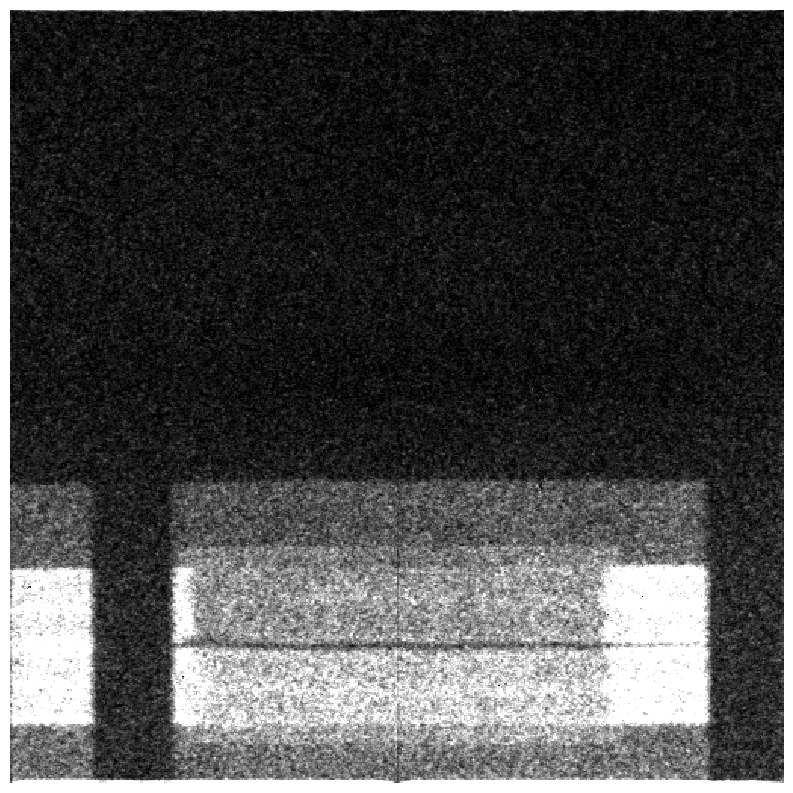

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
TIMESTMP= 'Tue Aug 24 18:42:58 2021'                                            
TIME_DAT=         1629823378.0                                                  
COMMENT User: Ricardo Carreon                                                   

In [7]:
test = test_dict['02_exp102_00'][0][10]
show_img(test[0])
test[1]

### give parameters according to the pre processing required

In [8]:
pre_proc_seq = [outlier_removal, binning_frames,  stack_averaging]
pre_proc_param = dict (threshold = 0, frames_binning_factor = 5)

### do the pre processing step

In [9]:
test_dict = pre_processing_step (test_dict, pre_proc_seq, pre_proc_param)

Processing Binning Frames: 100%|█████████████████| 2/2 [00:00<00:00,  2.72it/s]


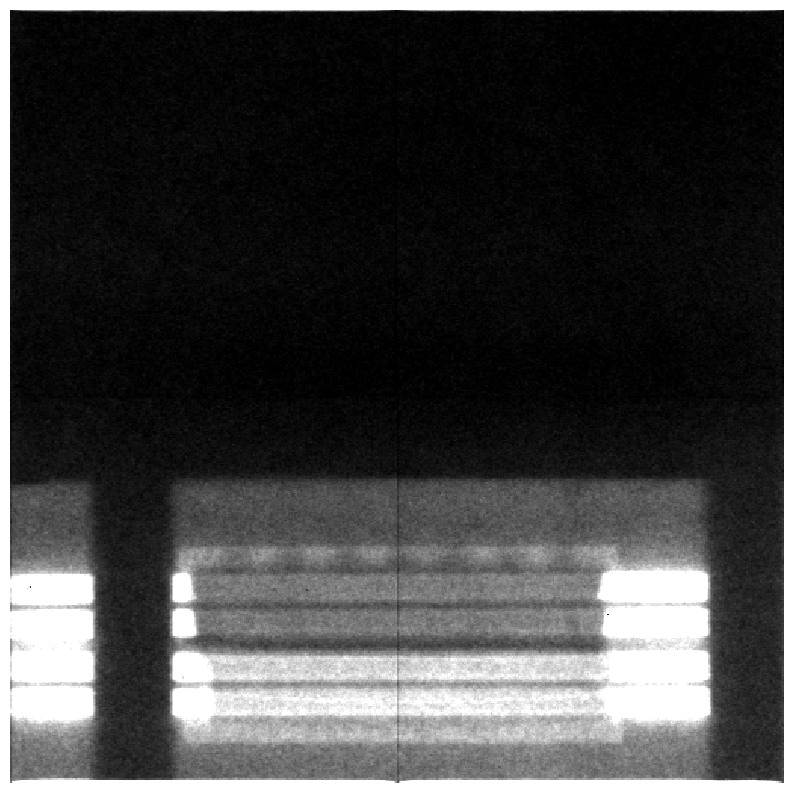

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
TIMESTMP= 'Tue Aug 24 18:46:38 2021'                                            
TIME_DAT=         1629823598.0                                                  
COMMENT User: Ricardo Carreon                                                   
HISTORY Sequence: ['outlier_removal']                                           
HISTORY Sequence: Frames binning. Binning: 5. Starting image: 0                 
HISTORY Sequence: Pulse average. X-axis (acquisitions)                          

In [10]:
test = test_dict['02_exp102_00'][0][10]
show_img(test[0])
test[1]

### parameters for testing img_registration_dict
because you may not wanna leave it automatically, specially for different energies or when it has artifacts

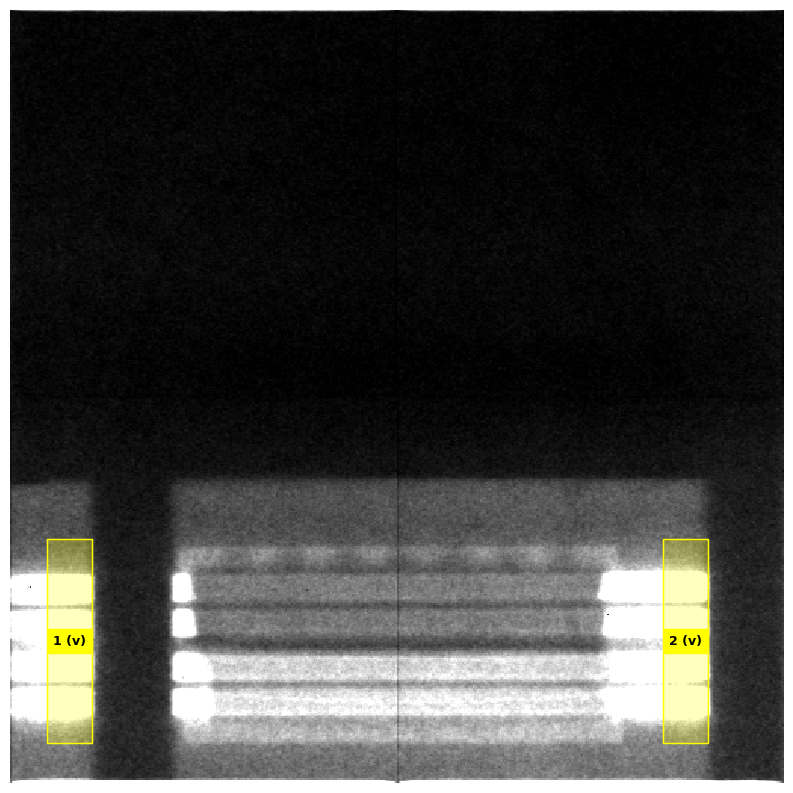

In [66]:
reg_img = get_img(src_dir + '/reg_img_LE2.fits')
reg_rois_list = [([24, 350, 30, 135], 'v'), ([432, 350, 30, 135], 'v')]

img = test_dict['02_exp102_00'][0][10]
show_img_rois(img[0], dr = [(reg_rois_list, 'yellow')])

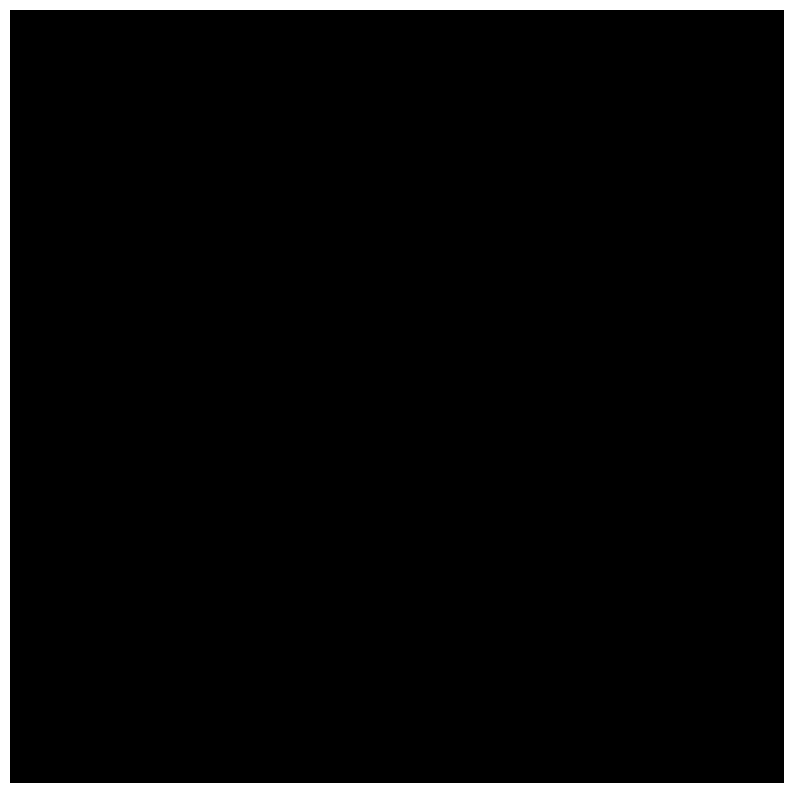

[[ 1.   0.  -0.1]
 [ 0.   1.   0. ]
 [ 0.   0.   1. ]]


In [67]:
img_reg_corr, M = img_registration (img, reg_img, reg_rois_list = reg_rois_list, dof=['ty'])

show_img(img_reg_corr[0]/reg_img[0], cmap = 'gray')
print(M)

### do the same pre_processing and processing for the reference key
if you are lucky, they will be the same as the one from the experiment

In [43]:
ref_dict, weights_DataFrame = testing_mode_step (src_dir, proc_folder = ref_folder, keep_acq_numb = 4)

pre_proc_seq = [outlier_removal, binning_frames,  stack_averaging]
pre_proc_param = dict (threshold = 0, frames_binning_factor = 5)
ref_dict = pre_processing_step (ref_dict, pre_proc_seq, pre_proc_param)

Processing Binning Frames: 100%|█████████████████| 2/2 [00:00<00:00,  2.73it/s]


In [58]:
BB_mask = get_img(src_dir + '/bb_mask2.fits')

In [59]:
# %load select_rois(img, list_rois = ['nca'])
nca = [406, 398, 47, 12]

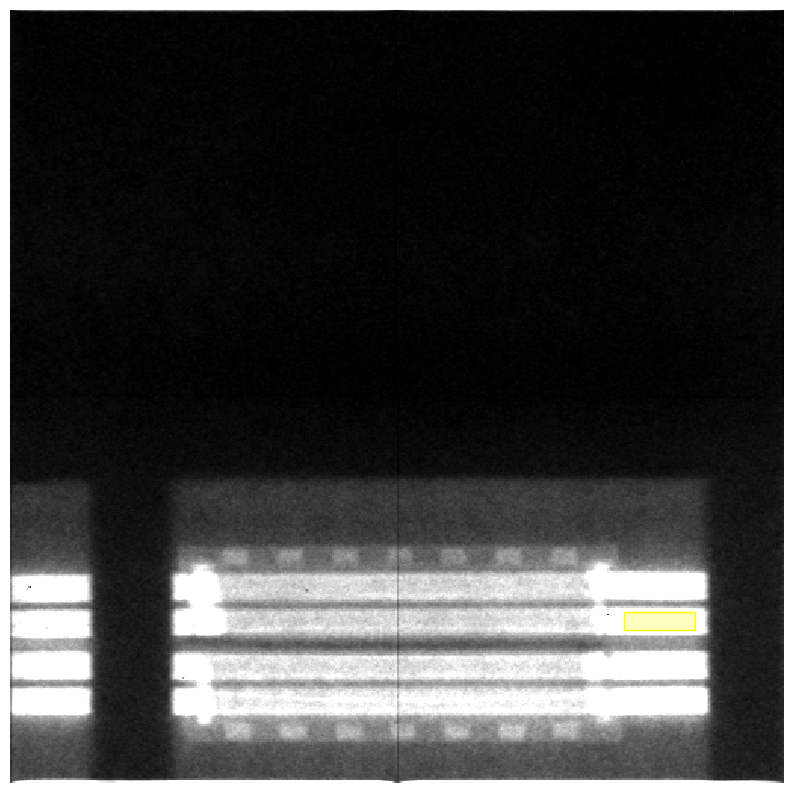

In [60]:
img_ref = ref_dict[ref_folder[0]][0][10]
show_img_rois(img_ref[0], dr = [(nca, 'yellow')])

In [61]:
proc_seq = ['scrubbing_correction_dict', 'SBKG_correction_dict']
list_proc_param = ['weights_DataFrame', 'BB_mask']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
ref_dict = processing_step (ref_dict, proc_seq, list_proc_dict)

Processing SBKG Correction: 100%|████████████████| 1/1 [00:01<00:00,  1.63s/it]


In [68]:
ref_img_TFC = avg_frames_dict (ref_dict[ref_folder[0]], output_type = 'img')
proc_seq = ['TFC_correction_dict']
list_proc_param = ['ref_img_TFC', 'nca']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
ref_dict = processing_step (ref_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|█████████████████| 1/1 [00:00<00:00, 18.73it/s]


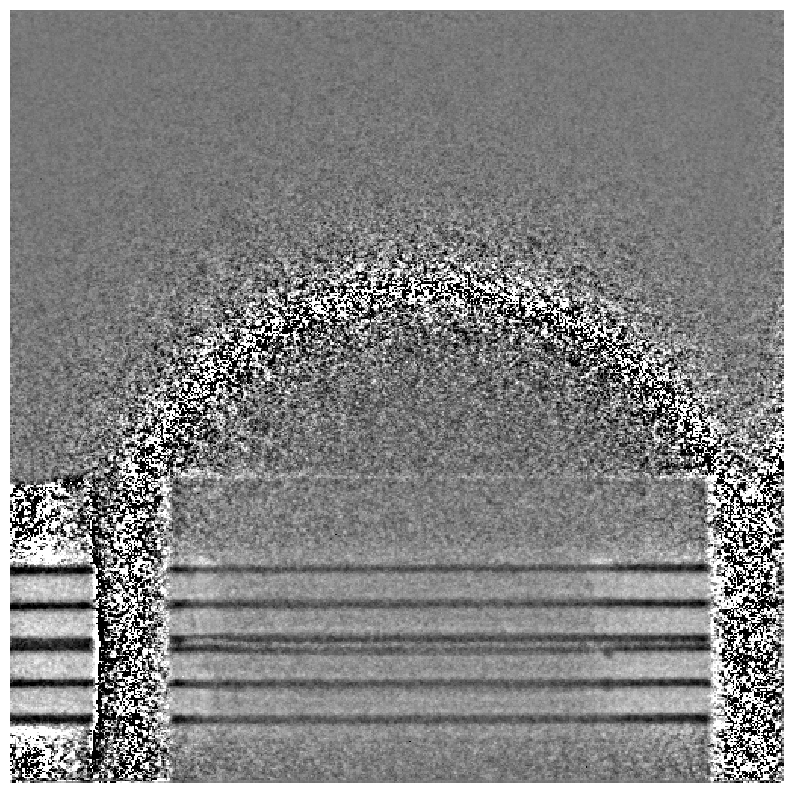

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
TIMESTMP= 'Tue Aug 24 12:02:12 2021'                                            
TIME_DAT=         1629799332.0                                                  
COMMENT User: Ricardo Carreon                                                   
COMMENT SBKG Image created on: 2022-06-20 10:05:40.771194                       
HISTORY Sequence: ['outlier_removal']                                           
HISTORY Sequence: Frames binning. Binning: 5. Starting image: 0                 
HISTORY Sequence: Pulse aver

In [69]:
test = ref_dict['01_so_ref'][0][10]
show_img(test[0])
test[1]

### give the BB_mask and nca for the processing

In [ ]:
BB_mask = get_img(src_dir + '/bb_mask2.fits')

In [ ]:
# %load select_rois(img, list_rois = ['nca'])
nca = [408, 400, 47, 12]

In [ ]:
show_img_rois(img, dr = [(reg_rois, 'yellow')])

### full processing in testing mode
a full sequence looks like this : ['scrubbing_correction_dict', 'image_registration_dict', 'SBKG_correction_dict', 'TFC_correction_dict']

### give all the parameters needed

In [ ]:
dof=['ty']
ref_img_TFC = avg_frames_dict (ref_dict[proc_ref[0]], output_type = 'img')

proc_seq = ['scrubbing_correction_dict', 'image_registration_dict', 'SBKG_correction_dict', 'TFC_correction_dict']
list_proc_param = ['weights_DataFrame', 'reg_img, reg_rois_list', 'dof', 'M', 'BB_mask', 'ref_img_TFC', 'nca']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)

In [ ]:
test_dict = processing_step (test_dict, proc_seq, list_proc_dict)